In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURE_PATH = Path('shm_engineered_features.csv')
dataset = pd.read_csv(FEATURE_PATH)
print('Dataset:', dataset.shape)
display(dataset.head())

Dataset: (64, 29)


,filename,n_samples,mean,std,min,max,range,median,q01,q05,...,zero_crossing_rate,diff_mean,diff_std,diff_abs_mean,diff_max_abs,fft_dominant_bin,fft_spectral_centroid,fft_low_power_ratio,fft_high_power_ratio,damage
0,train01.csv,581119,5.935087,8.631424,-19.343730,39.391250,58.734980,5.877941,-15.473143,-10.280573,...,0.040011,1.710272e-05,0.841824,0.655596,7.771517,6.0,0.002148,0.994855,0.001023,0.103663
1,train02.csv,581119,-7.732042,10.753985,-37.650806,25.297182,62.947988,-8.015717,-29.840237,-27.880156,...,0.033269,-2.043525e-05,0.524750,0.391346,15.854985,6.0,0.000945,0.997883,0.000349,0.149209
2,train03.csv,581119,1.926789,9.019788,-28.079456,29.944937,58.024393,1.963803,-22.896507,-14.864844,...,0.084045,3.343685e-06,0.669238,0.520277,7.160041,5.0,0.001741,0.995531,0.000809,0.111298
3,train04.csv,581119,-2.477910,6.969857,-54.097850,38.489470,92.587320,-2.595728,-18.591022,-14.313705,...,0.042286,-6.189841e-06,0.835037,0.648803,14.698496,6.0,0.006917,0.986333,0.001518,0.894736
4,train05.csv,581119,3.074603,8.830389,-19.364319,29.429405,48.793724,2.978921,-15.563205,-13.177941,...,0.033232,-3.731464e-07,0.476161,0.369375,7.802064,5.0,0.000807,0.998106,0.000395,0.054740


In [2]:
TARGET = 'damage'
ID_COLUMNS = ['filename']
X = dataset.drop(columns=ID_COLUMNS + [TARGET])
y = dataset[TARGET].astype(float)
X = X.replace([np.inf, -np.inf], np.nan)
print('Samples:', len(X), 'Features:', X.shape[1])
print('Target min/median/max:', y.min(), y.median(), y.max())

def competition_mape(y_true, y_pred):
    denominator = np.maximum(np.abs(np.asarray(y_true)), 1e-8)
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) / denominator))

def competition_score(y_true, y_pred):
    return max(0.0, 1.0 - competition_mape(y_true, y_pred))

Samples: 64 Features: 27
Target min/median/max: 0.028620288 0.098930746 0.928338975


In [3]:
def linear(model):
    return Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', model)])

def tree(model):
    return Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', model)])

models = {
    'Dummy median': linear(DummyRegressor(strategy='median')),
    'Ridge': linear(Ridge(alpha=10.0)),
    'ElasticNet': linear(ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=20000, random_state=42)),
    'Random Forest': tree(RandomForestRegressor(n_estimators=300, min_samples_leaf=2, max_features=0.7, random_state=42, n_jobs=-1)),
    'Extra Trees': tree(ExtraTreesRegressor(n_estimators=300, min_samples_leaf=2, max_features=0.8, random_state=42, n_jobs=-1)),
    'Gradient Boosting': tree(GradientBoostingRegressor(n_estimators=150, learning_rate=0.03, max_depth=2, loss='huber', random_state=42)),
}

In [4]:
from sklearn.base import clone

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

results = []
predictions = {}

for name, estimator in models.items():

    prediction_sum = np.zeros(len(y), dtype=float)
    prediction_count = np.zeros(len(y), dtype=int)

    for train_idx, valid_idx in cv.split(X, y):

        fitted_model = clone(estimator)

        fitted_model.fit(
            X.iloc[train_idx],
            y.iloc[train_idx]
        )

        fold_predictions = fitted_model.predict(
            X.iloc[valid_idx]
        )

        prediction_sum[valid_idx] += fold_predictions
        prediction_count[valid_idx] += 1

    if not np.all(prediction_count > 0):
        raise ValueError("Some samples received no validation prediction.")

    # Average each sample's predictions across repeated folds
    pred = prediction_sum / prediction_count

    predictions[name] = pred

    results.append({
        "model": name,
        "MAPE": competition_mape(y, pred),
        "competition_score": competition_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred)
    })

results = (
    pd.DataFrame(results)
    .sort_values("competition_score", ascending=False)
)

display(results)

,model,MAPE,competition_score,MAE,RMSE,R2
5,Gradient Boosting,0.210194,0.789806,0.039728,0.074434,0.918926
3,Random Forest,0.246156,0.753844,0.040651,0.075466,0.916660
4,Extra Trees,0.250535,0.749465,0.040901,0.075140,0.917380
1,Ridge,0.890797,0.109203,0.075141,0.095654,0.866109
2,ElasticNet,0.891360,0.108640,0.064094,0.081027,0.903927
0,Dummy median,0.936741,0.063259,0.181302,0.293660,-0.261931


Selected by competition score: Gradient Boosting


,filename,damage,prediction,absolute_error,percentage_error
39,train40.csv,0.178849,0.368901,0.190052,1.062640
55,train56.csv,0.040051,0.075589,0.035539,0.887350
11,train12.csv,0.054978,0.089839,0.034861,0.634081
37,train38.csv,0.035914,0.056543,0.020628,0.574379
6,train07.csv,0.028737,0.044492,0.015755,0.548225
63,train64.csv,0.280286,0.423370,0.143084,0.510492
3,train04.csv,0.894736,0.531682,0.363055,0.405767
58,train59.csv,0.091538,0.125351,0.033814,0.369396
17,train18.csv,0.375658,0.237348,0.138311,0.368182
44,train45.csv,0.187610,0.251611,0.064001,0.341136


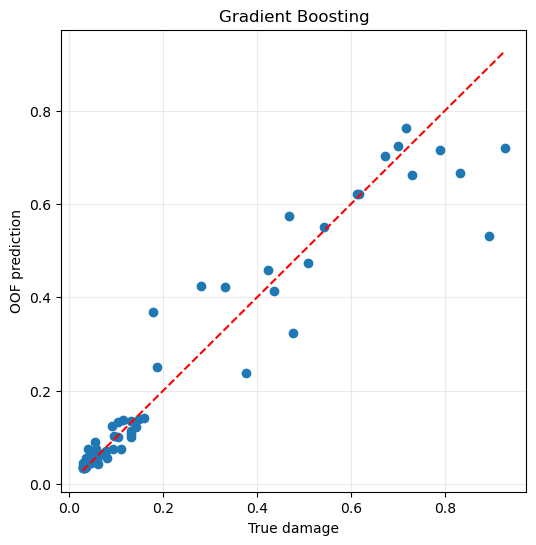

In [5]:
best_name = results.iloc[0]['model']
best_pred = predictions[best_name]
diagnostics = dataset[['filename','damage']].copy()
diagnostics['prediction'] = best_pred
diagnostics['absolute_error'] = np.abs(diagnostics.damage - diagnostics.prediction)
diagnostics['percentage_error'] = diagnostics.absolute_error / np.maximum(np.abs(diagnostics.damage), 1e-8)
print('Selected by competition score:', best_name)
display(diagnostics.sort_values('percentage_error', ascending=False).head(10))

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6)); plt.scatter(y, best_pred); plt.plot([y.min(),y.max()],[y.min(),y.max()], 'r--'); plt.xlabel('True damage'); plt.ylabel('OOF prediction'); plt.title(best_name); plt.grid(alpha=.25); plt.show()

In [6]:
results.to_csv('shm_model_validation_results.csv', index=False)
diagnostics.to_csv('shm_validation_diagnostics.csv', index=False)
print('Saved validation results and diagnostics.')

Saved validation results and diagnostics.
